# Descripción

La compañía de seguros Sure Tomorrow quiere resolver varias tareas con la ayuda de machine learning y te pide que evalúes esa posibilidad.

- Tarea 1: encontrar clientes que sean similares a un cliente determinado. Esto ayudará a los agentes de la compañía con el marketing.
- Tarea 2: predecir la probabilidad de que un nuevo cliente reciba una prestación del seguro. ¿Puede un modelo de predictivo funcionar mejor que un modelo dummy?
- Tarea 3: predecir el número de prestaciones de seguro que un nuevo cliente pueda recibir utilizando un modelo de regresión lineal.
- Tarea 4: proteger los datos personales de los clientes sin afectar al modelo del ejercicio anterior. 

Es necesario desarrollar un algoritmo de transformación de datos que dificulte la recuperación de la información personal si los datos caen en manos equivocadas. Esto se denomina enmascaramiento u ofuscación de datos. Pero los datos deben protegerse de tal manera que no se vea afectada la calidad de los modelos de machine learning. No es necesario elegir el mejor modelo, basta con demostrar que el algoritmo funciona correctamente.


# Preprocesamiento y exploración de datos

## Inicialización

In [105]:
import math
import numpy as np
import pandas as pd

import seaborn as sns

import sklearn.linear_model
import sklearn.metrics
import sklearn.neighbors
import sklearn.preprocessing

from sklearn.model_selection import train_test_split

from IPython.display import display

## Carga de datos

Carga los datos y haz una revisión básica para comprobar que no hay problemas obvios.

In [106]:
# ahora vamos a cargar los datos, primero desde la carpeta local y si no existe desde la ruta de la plataforma
try:
    df = pd.read_csv('insurance_us.csv')
except FileNotFoundError:
    df = pd.read_csv('/datasets/insurance_us.csv')

Renombramos las columnas para que el código se vea más coherente con su estilo.

In [107]:
df = df.rename(columns={'Gender': 'gender', 'Age': 'age', 'Salary': 'income', 'Family members': 'family_members', 'Insurance benefits': 'insurance_benefits'})

In [108]:
df.sample(10)

,gender,age,income,family_members,insurance_benefits
3201,0,31.0,30800.0,3,0
3154,1,29.0,39500.0,3,0
4056,0,38.0,56900.0,3,0
1872,1,27.0,43600.0,1,0
4351,1,25.0,33400.0,1,0
2278,0,49.0,60300.0,1,2
1502,1,32.0,47100.0,1,0
684,1,52.0,55800.0,1,2
644,1,20.0,34300.0,1,0
1065,0,35.0,53700.0,0,0


In [109]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 5 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   gender              5000 non-null   int64  
 1   age                 5000 non-null   float64
 2   income              5000 non-null   float64
 3   family_members      5000 non-null   int64  
 4   insurance_benefits  5000 non-null   int64  
dtypes: float64(2), int64(3)
memory usage: 195.4 KB


In [110]:
# puede que queramos cambiar el tipo de edad (de float a int) aunque esto no es crucial

# escribe tu conversión aquí si lo deseas:

# antes de convertir, vamos a comprobar que ninguna edad tenga decimales para no perder información
print('Edades con decimales:', (df['age'] % 1 != 0).sum())

df['age'] = df['age'].astype(int)

Edades con decimales: 0


In [111]:
# comprueba que la conversión se haya realizado con éxito
df['age'].dtype

dtype('int64')

In [112]:
# ahora echa un vistazo a las estadísticas descriptivas de los datos.
# ¿Se ve todo bien?
df.describe()

,gender,age,income,family_members,insurance_benefits
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,0.499000,30.952800,39916.360000,1.194200,0.148000
std,0.500049,8.440807,9900.083569,1.091387,0.463183
min,0.000000,18.000000,5300.000000,0.000000,0.000000
25%,0.000000,24.000000,33300.000000,0.000000,0.000000
50%,0.000000,30.000000,40200.000000,1.000000,0.000000
75%,1.000000,37.000000,46600.000000,2.000000,0.000000
max,1.000000,65.000000,79000.000000,6.000000,5.000000


In [113]:
# ahora vamos a revisar si hay valores ausentes en alguna columna
print('Valores ausentes por columna:')
print(df.isna().sum())

# ahora vamos a contar las filas duplicadas
print()
print('Filas duplicadas:', df.duplicated().sum())
print('Porcentaje de filas duplicadas:', round(df.duplicated().sum() / len(df) * 100, 2))

Valores ausentes por columna:
gender                0
age                   0
income                0
family_members        0
insurance_benefits    0
dtype: int64

Filas duplicadas: 153
Porcentaje de filas duplicadas: 3.06


In [114]:
# ahora vamos a buscar valores extremos en cada columna con la regla del rango intercuartil
for columna in ['age', 'income', 'family_members', 'insurance_benefits']:
    q1 = df[columna].quantile(0.25)
    q3 = df[columna].quantile(0.75)
    rango = q3 - q1
    limite_inferior = q1 - 1.5 * rango
    limite_superior = q3 + 1.5 * rango
    extremos = df[(df[columna] < limite_inferior) | (df[columna] > limite_superior)]
    print(columna, '| límites:', round(limite_inferior, 1), 'a', round(limite_superior, 1),
          '| valores extremos:', len(extremos), '| mínimo:', df[columna].min(), '| máximo:', df[columna].max())

# ahora vamos a ver cómo se reparten el número de familiares y el número de prestaciones
print()
print(df['family_members'].value_counts().sort_index())
print()
print(df['insurance_benefits'].value_counts().sort_index())

age | límites: 4.5 a 56.5 | valores extremos: 12 | mínimo: 18 | máximo: 65
income | límites: 13350.0 a 66550.0 | valores extremos: 37 | mínimo: 5300.0 | máximo: 79000.0
family_members | límites: -3.0 a 5.0 | valores extremos: 7 | mínimo: 0 | máximo: 6
insurance_benefits | límites: 0.0 a 0.0 | valores extremos: 564 | mínimo: 0 | máximo: 5

family_members
0    1513
1    1814
2    1071
3     439
4     124
5      32
6       7
Name: count, dtype: int64

insurance_benefits
0    4436
1     423
2     115
3      18
4       7
5       1
Name: count, dtype: int64


**¿Se ve todo bien?**

Sí, los datos están en buen estado para trabajar.

- No hay valores ausentes en ninguna de las cinco columnas.
- Hay 153 filas duplicadas, el 3.06 % del total. Decidí conservarlas porque no hay una columna que identifique a cada cliente y solo tenemos cuatro características: sexo, edad, ingreso y número de familiares. Con tan pocos datos por persona es normal que dos clientes distintos coincidan en todo.
- Busqué valores extremos con la regla del rango intercuartil, que marca los valores muy alejados de la mitad central de los datos. Encontré 12 en la edad (por encima de 56.5 años, con un máximo de 65), 37 en el ingreso (por debajo de 13350 o por encima de 66550, con un mínimo de 5300 y un máximo de 79000) y 7 en el número de familiares (clientes con 6). Todos son valores posibles, así que no eliminé ninguno.
- En 'insurance_benefits' la regla marca 564 valores extremos, pero no parecen ser errores. Como 4436 de los 5000 clientes no recibieron ninguna prestación, el rango intercuartil vale cero y cualquier cliente con al menos una prestación queda fuera de los límites.

## Análisis exploratorio de datos

Vamos a comprobar rápidamente si existen determinados grupos de clientes observando el gráfico de pares.

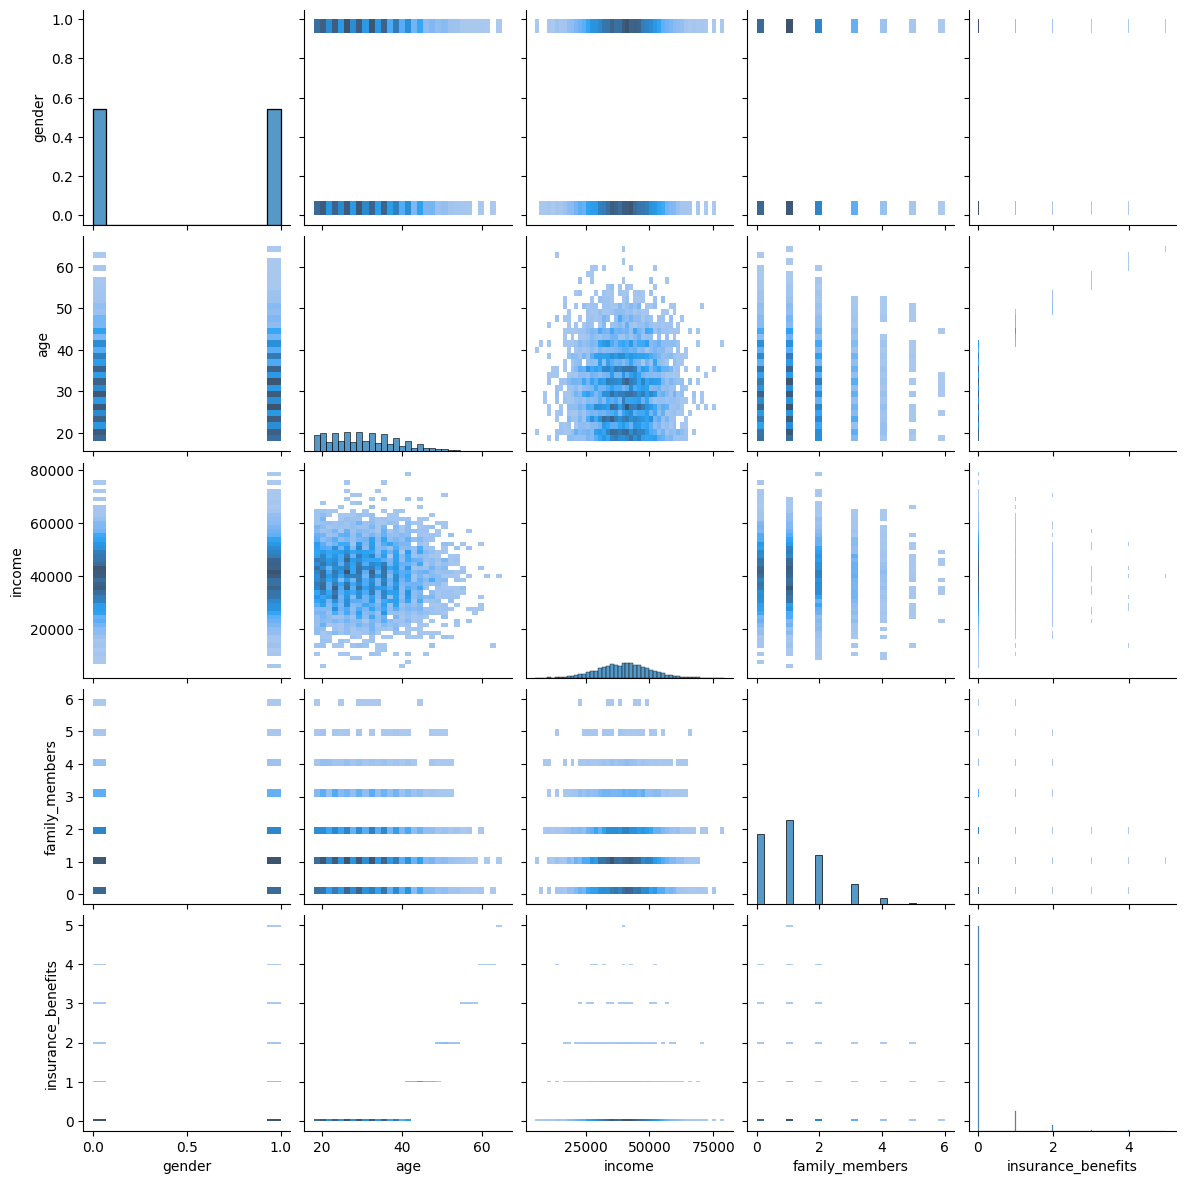

In [115]:
g = sns.pairplot(df, kind='hist')
g.fig.set_size_inches(12, 12)

De acuerdo, es un poco complicado detectar grupos obvios (clústeres) ya que es difícil combinar diversas variables simultáneamente (para analizar distribuciones multivariadas). Ahí es donde LA y ML pueden ser bastante útiles.

# Tarea 1. Clientes similares

En el lenguaje de ML, es necesario desarrollar un procedimiento que devuelva los k vecinos más cercanos (objetos) para un objeto dado basándose en la distancia entre los objetos.

Es posible que quieras revisar las siguientes lecciones (capítulo -> lección)
- Distancia entre vectores -> Distancia euclidiana
- Distancia entre vectores -> Distancia Manhattan

Para resolver la tarea, podemos probar diferentes métricas de distancia.

Escribe una función que devuelva los k vecinos más cercanos para un $n^{th}$ objeto basándose en una métrica de distancia especificada. A la hora de realizar esta tarea no debe tenerse en cuenta el número de prestaciones de seguro recibidas.

Puedes utilizar una implementación ya existente del algoritmo kNN de scikit-learn (consulta [el enlace](https://scikit-learn.org/stable/modules/generated/sklearn.neighbors.NearestNeighbors.html#sklearn.neighbors.NearestNeighbors)) o tu propia implementación.

Pruébalo para cuatro combinaciones de dos casos
- Escalado
  - los datos no están escalados
  - los datos se escalan con el escalador [MaxAbsScaler](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.MaxAbsScaler.html)
- Métricas de distancia
  - Euclidiana
  - Manhattan

Responde a estas preguntas:
- ¿El hecho de que los datos no estén escalados afecta al algoritmo kNN? Si es así, ¿cómo se manifiesta?
- ¿Qué tan similares son los resultados al utilizar la métrica de distancia Manhattan (independientemente del escalado)?

In [116]:
feature_names = ['gender', 'age', 'income', 'family_members']

In [117]:
def get_knn(df, n, k, metric):
    
    """
    Devuelve los k vecinos más cercanos

    :param df: DataFrame de pandas utilizado para encontrar objetos similares dentro del mismo lugar
    :param n: número de objetos para los que se buscan los vecinos más cercanos
    :param k: número de vecinos más cercanos a devolver
    :param métrica: nombre de la métrica de distancia
    """

    # ahora vamos a crear el modelo de vecinos más cercanos con la métrica elegida y entrenarlo con las características
    nbrs = sklearn.neighbors.NearestNeighbors(n_neighbors=k, metric=metric)
    nbrs.fit(df[feature_names].to_numpy())
    nbrs_distances, nbrs_indices = nbrs.kneighbors([df.iloc[n][feature_names]], k, return_distance=True)
    
    df_res = pd.concat([
        df.iloc[nbrs_indices[0]], 
        pd.DataFrame(nbrs_distances.T, index=nbrs_indices[0], columns=['distance'])
        ], axis=1)
    
    return df_res

Escalar datos.

In [118]:
feature_names = ['gender', 'age', 'income', 'family_members']

transformer_mas = sklearn.preprocessing.MaxAbsScaler().fit(df[feature_names].to_numpy())

df_scaled = df.copy()
# df_scaled.loc[:, feature_names] = transformer_mas.transform(df[feature_names].to_numpy())
# la línea anterior mostraba un aviso de pandas (FutureWarning) porque la edad y el número de familiares
# son columnas de enteros y el escalado devuelve decimales, por eso reemplazamos las columnas completas
df_scaled[feature_names] = transformer_mas.transform(df[feature_names].to_numpy())

In [119]:
df_scaled.sample(5)

,gender,age,income,family_members,insurance_benefits
3528,1.0,0.353846,0.426582,0.166667,0
2159,0.0,0.523077,0.472152,0.666667,0
2978,1.0,0.492308,0.517722,0.500000,0
2039,1.0,0.523077,0.477215,0.500000,0
2762,0.0,0.292308,0.641772,0.166667,0


Ahora, vamos a obtener registros similares para uno determinado, para cada combinación

In [120]:
# ahora vamos a buscar los 5 clientes más parecidos al cliente 0 con los datos sin escalar
n = 0
k = 5

print('Datos sin escalar, distancia euclidiana')
display(get_knn(df, n, k, 'euclidean'))

print('Datos sin escalar, distancia Manhattan')
display(get_knn(df, n, k, 'manhattan'))

Datos sin escalar, distancia euclidiana


,gender,age,income,family_members,insurance_benefits,distance
0,1,41,49600.0,1,0,0.000000
2022,1,41,49600.0,0,0,1.000000
1225,0,42,49600.0,0,1,1.732051
4031,1,44,49600.0,2,1,3.162278
3424,0,38,49600.0,0,0,3.316625


Datos sin escalar, distancia Manhattan


,gender,age,income,family_members,insurance_benefits,distance
0,1,41,49600.0,1,0,0.0
2022,1,41,49600.0,0,0,1.0
1225,0,42,49600.0,0,1,3.0
4031,1,44,49600.0,2,1,4.0
815,1,37,49600.0,2,0,5.0


In [121]:
# ahora vamos a repetir la búsqueda para el mismo cliente con los datos escalados
print('Datos escalados, distancia euclidiana')
display(get_knn(df_scaled, n, k, 'euclidean'))

print('Datos escalados, distancia Manhattan')
display(get_knn(df_scaled, n, k, 'manhattan'))

Datos escalados, distancia euclidiana


,gender,age,income,family_members,insurance_benefits,distance
0,1.0,0.630769,0.627848,0.166667,0,0.000000
2689,1.0,0.630769,0.634177,0.166667,0,0.006329
133,1.0,0.615385,0.636709,0.166667,0,0.017754
4869,1.0,0.646154,0.637975,0.166667,1,0.018418
3275,1.0,0.646154,0.651899,0.166667,1,0.028550


Datos escalados, distancia Manhattan


,gender,age,income,family_members,insurance_benefits,distance
0,1.0,0.630769,0.627848,0.166667,0,0.000000
2689,1.0,0.630769,0.634177,0.166667,0,0.006329
133,1.0,0.615385,0.636709,0.166667,0,0.024245
4869,1.0,0.646154,0.637975,0.166667,1,0.025511
2103,1.0,0.630769,0.596203,0.166667,0,0.031646


In [122]:
# un solo cliente es poca evidencia, así que ahora vamos a comparar las dos métricas en los primeros 100 clientes
# para cada cliente contamos cuántos de sus 5 vecinos son los mismos con la distancia euclidiana y con la Manhattan
def proporcion_coincidencias(datos, cliente, k):
    vecinos_euclidiana = list(get_knn(datos, cliente, k, 'euclidean').index)
    vecinos_manhattan = list(get_knn(datos, cliente, k, 'manhattan').index)
    iguales = 0
    for vecino in vecinos_euclidiana:
        if vecino in vecinos_manhattan:
            iguales = iguales + 1
    return iguales / k

coincidencias_sin_escalar = []
coincidencias_escalados = []
for cliente in range(100):
    coincidencias_sin_escalar.append(proporcion_coincidencias(df, cliente, k))
    coincidencias_escalados.append(proporcion_coincidencias(df_scaled, cliente, k))

print('Coincidencia media de vecinos, datos sin escalar:', round(np.mean(coincidencias_sin_escalar) * 100, 1), '%')
print('Coincidencia media de vecinos, datos escalados:', round(np.mean(coincidencias_escalados) * 100, 1), '%')

Coincidencia media de vecinos, datos sin escalar: 95.6 %
Coincidencia media de vecinos, datos escalados: 91.8 %


Respuestas a las preguntas

**¿El hecho de que los datos no estén escalados afecta al algoritmo kNN? Si es así, ¿cómo se manifiesta?** 

Sí, lo afecta mucho. kNN elige a los clientes con menor distancia, y esa distancia junta las diferencias de todas las características. Sin escalar, el ingreso está en decenas de miles (49600 en el cliente 0), mientras que la edad, el sexo y el número de familiares son números pequeños. Por eso casi toda la distancia depende del ingreso.

Se ve claro con el cliente 0, que tiene sexo 1, 41 años, un ingreso de 49600 y 1 familiar:

- Sin escalar, los 5 vecinos tienen exactamente el mismo ingreso, 49600, pero sus edades van de 38 a 44 años con la distancia euclidiana y de 37 a 44 con la Manhattan, hay clientes de los dos sexos y el número de familiares va de 0 a 2. En la práctica el algoritmo solo buscó personas con el mismo ingreso.
- Con los datos escalados, MaxAbsScaler divide cada característica entre su máximo (65 en la edad, 79000 en el ingreso y 6 en los familiares, según describe()), así que todas quedan entre 0 y 1 y el ingreso deja de dominar la distancia. Ahora los 5 vecinos tienen el mismo sexo y el mismo número de familiares que el cliente 0 (0.166667 × 6 = 1 familiar), y su edad escalada va de 0.615 a 0.646 frente a 0.631 del cliente, es decir, de 40 a 42 años frente a 41. El ingreso cambia un poco. Aun así, el peso no queda repartido por igual: cambiar de sexo suma 1 a la distancia y tener un familiar más suma 0.167, mientras que un año de edad solo suma 0.015. Por eso ahora el algoritmo prioriza que coincidan el sexo y los familiares. Aun así, son clientes mucho más parecidos en todo, que es lo que buscan los agentes para el marketing.

**¿Qué tan similares son los resultados al utilizar la métrica de distancia Manhattan (independientemente del escalado)?** 

Como un solo cliente es poca evidencia, lo comprobé con los primeros 100 clientes. En promedio coinciden el 95.6 % de los vecinos con los datos sin escalar y el 91.8 % con los datos escalados. Sin escalar coinciden un poco más, probablemente porque las dos métricas dependen casi solo del ingreso. Hay que tener en cuenta que el primer vecino es el propio cliente, con distancia 0, y ese siempre coincide, pero aun así las dos métricas llevan casi a los mismos clientes.

# Tarea 2. ¿Es probable que el cliente reciba una prestación del seguro?

En términos de machine learning podemos considerarlo como una tarea de clasificación binaria.

Con el valor de `insurance_benefits` superior a cero como objetivo, evalúa si el enfoque de clasificación kNN puede funcionar mejor que el modelo dummy.

Instrucciones:
- Construye un clasificador basado en KNN y mide su calidad con la métrica F1 para k=1...10 tanto para los datos originales como para los escalados. Sería interesante observar cómo k puede influir en la métrica de evaluación y si el escalado de los datos provoca alguna diferencia. Puedes utilizar una implementación ya existente del algoritmo de clasificación kNN de scikit-learn (consulta [el enlace](https://scikit-learn.org/stable/modules/generated/sklearn.neighbors.KNeighborsClassifier.html)) o tu propia implementación.
- Construye un modelo dummy que, en este caso, es simplemente un modelo aleatorio. Debería devolver "1" con cierta probabilidad. Probemos el modelo con cuatro valores de probabilidad: 0, la probabilidad de pagar cualquier prestación del seguro, 0.5, 1.

La probabilidad de pagar cualquier prestación del seguro puede definirse como

$$
P\{\text{prestación de seguro recibida}\}=\frac{\text{número de clientes que han recibido alguna prestación de seguro}}{\text{número total de clientes}}.
$$

Divide todos los datos correspondientes a las etapas de entrenamiento/prueba respetando la proporción 70:30.

In [123]:
# сalcula el objetivo

# si insurance_benefits es mayor que 0, el cliente recibió al menos una prestación
df['insurance_benefits_received'] = (df['insurance_benefits'] > 0).astype(int)

In [124]:
# comprueba el desequilibrio de clases con value_counts()

print(df['insurance_benefits_received'].value_counts())
print()
print(df['insurance_benefits_received'].value_counts(normalize=True))

insurance_benefits_received
0    4436
1     564
Name: count, dtype: int64

insurance_benefits_received
0    0.8872
1    0.1128
Name: proportion, dtype: float64


In [125]:
def eval_classifier(y_true, y_pred):
    
    f1_score = sklearn.metrics.f1_score(y_true, y_pred)
    print(f'F1: {f1_score:.2f}')
    
# si tienes algún problema con la siguiente línea, reinicia el kernel y ejecuta el cuaderno de nuevo
    cm = sklearn.metrics.confusion_matrix(y_true, y_pred, normalize='all')
    print('Matriz de confusión')
    print(cm)

In [126]:
# generar la salida de un modelo aleatorio

def rnd_model_predict(P, size, seed=42):

    rng = np.random.default_rng(seed=seed)
    return rng.binomial(n=1, p=P, size=size)

In [127]:
for P in [0, df['insurance_benefits_received'].sum() / len(df), 0.5, 1]:

    print(f'La probabilidad: {P:.2f}')
    y_pred_rnd = rnd_model_predict(P, size=len(df))
        
    eval_classifier(df['insurance_benefits_received'], y_pred_rnd)
    
    print()

La probabilidad: 0.00
F1: 0.00
Matriz de confusión
[[0.8872 0.    ]
 [0.1128 0.    ]]

La probabilidad: 0.11
F1: 0.12
Matriz de confusión
[[0.7914 0.0958]
 [0.0994 0.0134]]

La probabilidad: 0.50
F1: 0.20
Matriz de confusión
[[0.456  0.4312]
 [0.053  0.0598]]

La probabilidad: 1.00
F1: 0.20
Matriz de confusión
[[0.     0.8872]
 [0.     0.1128]]



In [128]:
# dividimos en entrenamiento y prueba (70:30), una vez con los datos originales y otra con los escalados
# con el mismo random_state las dos divisiones toman las mismas filas
X_train, X_test, y_train, y_test = train_test_split(
    df[feature_names], df['insurance_benefits_received'], test_size=0.3, random_state=12345)

# el objetivo sale de df porque df_scaled se creó antes de añadir esa columna, y el objetivo no se escala
X_train_scaled, X_test_scaled, y_train_scaled, y_test_scaled = train_test_split(
    df_scaled[feature_names], df['insurance_benefits_received'], test_size=0.3, random_state=12345)

print('Filas de entrenamiento:', len(X_train), '| filas de prueba:', len(X_test))
print('Proporción de clientes con prestación en entrenamiento:', round(y_train.mean(), 3))
print('Proporción de clientes con prestación en prueba:', round(y_test.mean(), 3))

Filas de entrenamiento: 3500 | filas de prueba: 1500
Proporción de clientes con prestación en entrenamiento: 0.115
Proporción de clientes con prestación en prueba: 0.109


In [129]:
# entrena un kNN para cada k de 1 a 10 y devuelve el F1 de cada uno en la muestra de prueba
def f1_por_k(X_train, X_test, y_train, y_test):
    resultados = []
    for k in range(1, 11):
        modelo = sklearn.neighbors.KNeighborsClassifier(n_neighbors=k)
        modelo.fit(X_train.to_numpy(), y_train)
        predicciones = modelo.predict(X_test.to_numpy())
        f1 = sklearn.metrics.f1_score(y_test, predicciones)
        resultados.append(f1)
        print('k =', k, '| F1:', round(f1, 2))
    return resultados

print('Datos originales')
f1_originales = f1_por_k(X_train, X_test, y_train, y_test)

Datos originales
k = 1 | F1: 0.61
k = 2 | F1: 0.41
k = 3 | F1: 0.41
k = 4 | F1: 0.28
k = 5 | F1: 0.27
k = 6 | F1: 0.11
k = 7 | F1: 0.11
k = 8 | F1: 0.07
k = 9 | F1: 0.08
k = 10 | F1: 0.0


In [130]:
print('Datos escalados')
f1_escalados = f1_por_k(X_train_scaled, X_test_scaled, y_train_scaled, y_test_scaled)

# matriz de confusión del mejor k en cada caso
mejor_k_originales = f1_originales.index(max(f1_originales)) + 1
mejor_k_escalados = f1_escalados.index(max(f1_escalados)) + 1

print()
print('Datos originales, mejor k:', mejor_k_originales)
modelo_originales = sklearn.neighbors.KNeighborsClassifier(n_neighbors=mejor_k_originales)
modelo_originales.fit(X_train.to_numpy(), y_train)
eval_classifier(y_test, modelo_originales.predict(X_test.to_numpy()))

print()
print('Datos escalados, mejor k:', mejor_k_escalados)
modelo_escalados = sklearn.neighbors.KNeighborsClassifier(n_neighbors=mejor_k_escalados)
modelo_escalados.fit(X_train_scaled.to_numpy(), y_train_scaled)
eval_classifier(y_test_scaled, modelo_escalados.predict(X_test_scaled.to_numpy()))

Datos escalados
k = 1 | F1: 0.97
k = 2 | F1: 0.93
k = 3 | F1: 0.95
k = 4 | F1: 0.91
k = 5 | F1: 0.92
k = 6 | F1: 0.9
k = 7 | F1: 0.92
k = 8 | F1: 0.9
k = 9 | F1: 0.92
k = 10 | F1: 0.88

Datos originales, mejor k: 1
F1: 0.61
Matriz de confusión
[[0.87133333 0.02      ]
 [0.05266667 0.056     ]]

Datos escalados, mejor k: 1
F1: 0.97
Matriz de confusión
[[0.88866667 0.00266667]
 [0.00466667 0.104     ]]


**¿Puede un modelo entrenado funcionar mejor que un modelo dummy? ¿Puede funcionar peor?**

Sí, puede funcionar mucho mejor. El modelo aleatorio no aprende nada de los clientes, solo dice "sí" con cierta probabilidad. Su mejor F1 fue 0.20, con p = 0.5 y con p = 1. Con la probabilidad real, 0.11, se quedó en 0.12, y con p = 0 el F1 es 0 porque nunca detecta a un cliente con prestación.

Con los datos escalados, el kNN obtuvo un F1 de entre 0.88 y 0.97 para k de 1 a 10, muy por encima del modelo aleatorio. El mejor fue k = 1, con 0.97, y en su matriz de confusión los errores no llegan al 1 % de los clientes de prueba.

Pero un modelo entrenado también puede funcionar peor. Con los datos sin escalar, el F1 baja de 0.61 con k = 1 a 0 con k = 10, por debajo del modelo aleatorio. Pasa lo mismo que en la tarea 1: sin escalar, los vecinos se eligen casi solo por el ingreso y no se parecen de verdad al cliente. Como el 88.7 % de los clientes no recibió ninguna prestación, al tomar más vecinos casi siempre gana la mayoría y el modelo deja de detectar a los clientes con prestación.

En los dos casos el F1 tiende a bajar cuando sube k, pero con los datos escalados baja muy poco. Por eso para este modelo el escalado es necesario.

# Tarea 3. Regresión (con regresión lineal)

Con `insurance_benefits` como objetivo, evalúa cuál sería la RECM de un modelo de regresión lineal.

Construye tu propia implementación de regresión lineal. Para ello, recuerda cómo está formulada la solución de la tarea de regresión lineal en términos de LA. Comprueba la RECM tanto para los datos originales como para los escalados. ¿Puedes ver alguna diferencia en la RECM con respecto a estos dos casos?

Denotemos
- $X$: matriz de características; cada fila es un caso, cada columna es una característica, la primera columna está formada por unidades
- $y$ — objetivo (un vector)
- $\hat{y}$ — objetivo estimado (un vector)
- $w$ — vector de pesos

La tarea de regresión lineal en el lenguaje de las matrices puede formularse así:

$$
y = Xw
$$

El objetivo de entrenamiento es entonces encontrar esa $w$ w que minimice la distancia L2 (ECM) entre $Xw$ y $y$:

$$
\min_w d_2(Xw, y) \quad \text{or} \quad \min_w \text{MSE}(Xw, y)
$$

Parece que hay una solución analítica para lo anteriormente expuesto:

$$
w = (X^T X)^{-1} X^T y
$$

La fórmula anterior puede servir para encontrar los pesos $w$ y estos últimos pueden utilizarse para calcular los valores predichos

$$
\hat{y} = X_{val}w
$$

Divide todos los datos correspondientes a las etapas de entrenamiento/prueba respetando la proporción 70:30. Utiliza la métrica RECM para evaluar el modelo.

In [131]:
class MyLinearRegression:
    
    def __init__(self):
        
        self.weights = None
    
    def fit(self, X, y):
        
        # añadir las unidades
        X2 = np.append(np.ones([len(X), 1]), X, axis=1)
        # pesos con la fórmula w = (X^T X)^-1 X^T y
        self.weights = np.linalg.inv(X2.T.dot(X2)).dot(X2.T).dot(y)

    def predict(self, X):
        
        # añadir las unidades
        X2 = np.append(np.ones([len(X), 1]), X, axis=1)
        y_pred = X2.dot(self.weights)
        
        return y_pred

In [132]:
def eval_regressor(y_true, y_pred):
    
    rmse = math.sqrt(sklearn.metrics.mean_squared_error(y_true, y_pred))
    print(f'RMSE: {rmse:.2f}')
    
    # r2_score = math.sqrt(sklearn.metrics.r2_score(y_true, y_pred))
    # la línea anterior le sacaba la raíz al R2: mostraba 0.66 cuando el R2 real es 0.43,
    # y con el modelo de referencia, que tiene un R2 negativo, daba error (math domain error), por eso quitamos la raíz
    r2_score = sklearn.metrics.r2_score(y_true, y_pred)
    print(f'R2: {r2_score:.2f}')    

In [133]:
X = df[['age', 'gender', 'income', 'family_members']].to_numpy()
y = df['insurance_benefits'].to_numpy()

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=12345)

lr = MyLinearRegression()

lr.fit(X_train, y_train)
print(lr.weights)

y_test_pred = lr.predict(X_test)
eval_regressor(y_test, y_test_pred)

[-9.43539012e-01  3.57495491e-02  1.64272726e-02 -2.60743659e-07
 -1.16902127e-02]
RMSE: 0.34
R2: 0.43


In [134]:
# repetimos la regresión con los datos escalados, con las mismas filas de entrenamiento y prueba
X_scaled = df_scaled[['age', 'gender', 'income', 'family_members']].to_numpy()

X_train_scaled, X_test_scaled, y_train_scaled, y_test_scaled = train_test_split(X_scaled, y, test_size=0.3, random_state=12345)

lr_scaled = MyLinearRegression()

lr_scaled.fit(X_train_scaled, y_train_scaled)
print(lr_scaled.weights)

y_test_pred_scaled = lr_scaled.predict(X_test_scaled)
eval_regressor(y_test_scaled, y_test_pred_scaled)

# comparamos las predicciones de los dos modelos
print('Diferencia máxima entre las predicciones:', np.abs(y_test_pred - y_test_pred_scaled).max())

[-0.94353901  2.32372069  0.01642727 -0.02059875 -0.07014128]
RMSE: 0.34
R2: 0.43
Diferencia máxima entre las predicciones: 2.042810365310288e-14


In [135]:
# como referencia, calculamos la RECM de un modelo que siempre predice la media de prestaciones del entrenamiento
y_pred_media = np.ones(len(y_test)) * y_train.mean()
print('Media de prestaciones en entrenamiento:', round(y_train.mean(), 2))
eval_regressor(y_test, y_pred_media)

Media de prestaciones en entrenamiento: 0.15
RMSE: 0.46
R2: -0.00


**¿Puedes ver alguna diferencia en la RECM con respecto a estos dos casos?**

No, no hay diferencia. La RECM fue 0.34 con los datos originales y con los escalados, y el R2 fue 0.43 en los dos casos. Las predicciones de los dos modelos son prácticamente iguales, la diferencia más grande entre ellas es menor que 0.0000000000001, que es solo redondeo de la computadora.

Lo que sí cambia son los pesos. Al escalar, cada característica se divide entre su máximo y el modelo lo compensa con un peso más grande en la misma proporción. Por ejemplo, el peso de la edad pasa de 0.036 a 2.32, que es 0.036 multiplicado por 65. Por eso las predicciones no cambian. Al contrario de lo que pasó con kNN, a la regresión lineal no le afecta el escalado.

También lo comparé con un modelo que siempre predice la media de prestaciones del entrenamiento, 0.15. Ese modelo tiene una RECM de 0.46, así que la regresión, con 0.34, se equivoca menos. Aun así, un R2 de 0.43 indica que el modelo solo explica una parte de lo que pasa con las prestaciones.

# Tarea 4. Ofuscar datos

Lo mejor es ofuscar los datos multiplicando las características numéricas (recuerda que se pueden ver como la matriz $X$) por una matriz invertible $P$. 

$$
X' = X \times P
$$

Trata de hacerlo y comprueba cómo quedarán los valores de las características después de la transformación. Por cierto, la propiedad de invertibilidad es importante aquí, así que asegúrate de que $P$ sea realmente invertible.

Puedes revisar la lección 'Matrices y operaciones matriciales -> Multiplicación de matrices' para recordar la regla de multiplicación de matrices y su implementación con NumPy.

In [136]:
personal_info_column_list = ['gender', 'age', 'income', 'family_members']
df_pn = df[personal_info_column_list]

In [137]:
X = df_pn.to_numpy()

Generar una matriz aleatoria $P$.

In [138]:
rng = np.random.default_rng(seed=42)
P = rng.random(size=(X.shape[1], X.shape[1]))

Comprobar que la matriz P sea invertible

In [139]:
# si el determinante de P no es cero, la matriz es invertible
print('Determinante de P:', np.linalg.det(P))

# calculamos la inversa y comprobamos que P por su inversa da la matriz identidad
# (los -0. que aparecen son números negativos tan pequeños que al redondear quedan en cero)
P_inv = np.linalg.inv(P)
print()
print('P por su inversa:')
print(np.round(P.dot(P_inv), 2))

Determinante de P: 0.24339135998015468

P por su inversa:
[[ 1.  0. -0. -0.]
 [ 0.  1. -0.  0.]
 [ 0.  0.  1.  0.]
 [-0. -0. -0.  1.]]


¿Puedes adivinar la edad o los ingresos de los clientes después de la transformación?

In [140]:
# ofuscamos los datos multiplicando la matriz de características por P
X_ofuscada = X.dot(P)

# mostramos los primeros clientes para ver cómo quedan los valores
df_ofuscado = pd.DataFrame(X_ofuscada, columns=['columna_1', 'columna_2', 'columna_3', 'columna_4'])
display(df_ofuscado.head())

# revisamos si las columnas ofuscadas se parecen a la edad o al ingreso originales
print()
for columna in df_ofuscado.columns:
    print(columna, '| correlación con la edad:', round(df_ofuscado[columna].corr(df_pn['age']), 2),
          '| correlación con el ingreso:', round(df_ofuscado[columna].corr(df_pn['income']), 2))

,columna_1,columna_2,columna_3,columna_4
0,6359.715273,22380.404676,18424.090742,46000.696690
1,4873.294065,17160.367030,14125.780761,35253.455773
2,2693.117429,9486.397744,7808.831560,19484.860631
3,5345.603937,18803.227203,15479.148373,38663.061863
4,3347.176735,11782.829283,9699.998942,24211.273378



columna_1 | correlación con la edad: -0.02 | correlación con el ingreso: 1.0
columna_2 | correlación con la edad: -0.02 | correlación con el ingreso: 1.0
columna_3 | correlación con la edad: -0.02 | correlación con el ingreso: 1.0
columna_4 | correlación con la edad: -0.02 | correlación con el ingreso: 1.0


No se pueden leer directamente. Después de multiplicar por $P$, cada columna mezcla el sexo, la edad, el ingreso y el número de familiares, así que los valores ya no se parecen a los originales. La edad queda bien escondida, porque su correlación con las columnas ofuscadas es de -0.02.

Con el ingreso hay que tener cuidado. Como sus valores son mucho más grandes que los de las otras características, es el que más pesa en la mezcla, y las cuatro columnas ofuscadas tienen una correlación de 1.0 con el ingreso original. Eso quiere decir que no se puede saber cuánto gana un cliente, pero sí se podría saber qué clientes ganan más que otros.

¿Puedes recuperar los datos originales de $X'$ si conoces $P$? Intenta comprobarlo a través de los cálculos moviendo $P$ del lado derecho de la fórmula anterior al izquierdo. En este caso las reglas de la multiplicación matricial son realmente útiles

In [141]:
# como X' = X × P, si multiplicamos X' por la inversa de P volvemos a X
X_recuperada = X_ofuscada.dot(P_inv)

# revisamos los primeros clientes recuperados, redondeados a 2 decimales
display(pd.DataFrame(X_recuperada, columns=personal_info_column_list).round(2).head())

,gender,age,income,family_members
0,1.0,41.0,49600.0,1.0
1,0.0,46.0,38000.0,1.0
2,-0.0,29.0,21000.0,-0.0
3,-0.0,21.0,41700.0,2.0
4,1.0,28.0,26100.0,-0.0


Sí. Si se conoce $P$, los datos se pueden recuperar. Partimos de $X' = X P$ y multiplicamos los dos lados por la derecha por la inversa de $P$:

$$
X' P^{-1} = X P P^{-1} = X I = X
$$

En la tabla, los primeros clientes recuperados tienen los mismos valores que los originales. Por eso $P$ se debe guardar en secreto, porque quien la tenga puede deshacer la ofuscación.

Muestra los tres casos para algunos clientes
- Datos originales
- El que está transformado
- El que está invertido (recuperado)

In [142]:
# mostramos los tres casos para los primeros 3 clientes
print('Datos originales')
display(df_pn.head(3))

print('Datos ofuscados')
display(df_ofuscado.head(3))

print('Datos recuperados')
display(pd.DataFrame(X_recuperada[:3], columns=personal_info_column_list))

Datos originales


,gender,age,income,family_members
0,1,41,49600.0,1
1,0,46,38000.0,1
2,0,29,21000.0,0


Datos ofuscados


,columna_1,columna_2,columna_3,columna_4
0,6359.715273,22380.404676,18424.090742,46000.696690
1,4873.294065,17160.367030,14125.780761,35253.455773
2,2693.117429,9486.397744,7808.831560,19484.860631


Datos recuperados


,gender,age,income,family_members
0,1.000000e+00,41.0,49600.0,1.000000e+00
1,1.679528e-12,46.0,38000.0,1.000000e+00
2,-6.230214e-13,29.0,21000.0,-2.030327e-13


Seguramente puedes ver que algunos valores no son exactamente iguales a los de los datos originales. ¿Cuál podría ser la razón de ello?

In [143]:
# comparamos todos los datos originales con los recuperados
diferencias = np.abs(X - X_recuperada)
print('Diferencia máxima entre original y recuperado:', diferencias.max())
print('Edad del primer cliente recuperada, sin redondear:', X_recuperada[0, 1])

Diferencia máxima entre original y recuperado: 2.1827872842550278e-11
Edad del primer cliente recuperada, sin redondear: 40.99999999999998


La razón es que la computadora guarda los números con decimales usando una cantidad limitada de cifras. Al multiplicar por $P$ y después por su inversa, que tienen muchos decimales, se acumulan pequeños errores de redondeo. Por eso la edad del primer cliente sale como 40.99999999999487 en lugar de 41, y algunos ceros salen como números muy pequeños, del orden de 0.000000000001. La diferencia más grande en todos los datos es de unas 0.00000000002 (se ve como e-11 en la salida), así que en la práctica los datos recuperados son iguales a los originales.

## Prueba de que la ofuscación de datos puede funcionar con regresión lineal

En este proyecto la tarea de regresión se ha resuelto con la regresión lineal. Tu siguiente tarea es demostrar _analytically_ que el método de ofuscación no afectará a la regresión lineal en términos de valores predichos, es decir, que sus valores seguirán siendo los mismos. ¿Lo puedes creer? Pues no hace falta que lo creas, ¡tienes que que demostrarlo!

Entonces, los datos están ofuscados y ahora tenemos $X \times P$ en lugar de tener solo $X$. En consecuencia, hay otros pesos $w_P$ como
$$
w = (X^T X)^{-1} X^T y \quad \Rightarrow \quad w_P = [(XP)^T XP]^{-1} (XP)^T y
$$

¿Cómo se relacionarían $w$ y $w_P$ si simplificáramos la fórmula de $w_P$ anterior? 

¿Cuáles serían los valores predichos con $w_P$? 

¿Qué significa esto para la calidad de la regresión lineal si esta se mide mediante la RECM?

Revisa el Apéndice B Propiedades de las matrices al final del cuaderno. ¡Allí encontrarás fórmulas muy útiles!

No es necesario escribir código en esta sección, basta con una explicación analítica.

**Respuesta**

Los pesos con los datos ofuscados son los pesos originales multiplicados por la inversa de $P$: $w_P = P^{-1} w$.

Los valores predichos no cambian, porque $X P w_P = X P P^{-1} w = X w$, que son las mismas predicciones que con los datos originales.

Como las predicciones son las mismas, la RECM también es la misma. La ofuscación no afecta a la calidad de la regresión lineal.

**Prueba analítica**

Partimos de la fórmula de los pesos con los datos ofuscados:

$$
w_P = [(XP)^T XP]^{-1} (XP)^T y
$$

1. La transpuesta de un producto se invierte de orden, $(XP)^T = P^T X^T$:

$$
w_P = [P^T X^T X P]^{-1} P^T X^T y
$$

2. La inversa de un producto también se invierte de orden, $(AB)^{-1} = B^{-1} A^{-1}$. Aplicándola dos veces a $P^T \cdot (X^T X) \cdot P$ (para esto $P$ tiene que ser invertible):

$$
w_P = P^{-1} (X^T X)^{-1} (P^T)^{-1} P^T X^T y
$$

3. Una matriz por su inversa da la identidad, $(P^T)^{-1} P^T = I$, y multiplicar por $I$ no cambia nada:

$$
w_P = P^{-1} (X^T X)^{-1} X^T y
$$

4. Lo que queda después de $P^{-1}$ es justo la fórmula de los pesos originales $w$:

$$
w_P = P^{-1} w
$$

5. Con esos pesos, las predicciones con los datos ofuscados son:

$$
\hat{y}_P = X P w_P = X P P^{-1} w = X I w = X w = \hat{y}
$$

Las predicciones son las mismas que con los datos originales, así que la RECM tampoco cambia.

## Prueba de regresión lineal con ofuscación de datos

Ahora, probemos que la regresión lineal pueda funcionar, en términos computacionales, con la transformación de ofuscación elegida.

Construye un procedimiento o una clase que ejecute la regresión lineal opcionalmente con la ofuscación. Puedes usar una implementación de regresión lineal de scikit-learn o tu propia implementación.

Ejecuta la regresión lineal para los datos originales y los ofuscados, compara los valores predichos y los valores de las métricas RMSE y $R^2$. ¿Hay alguna diferencia?

**Procedimiento**

- Crea una matriz cuadrada $P$ de números aleatorios.
- Comprueba que sea invertible. Si no lo es, repite el primer paso hasta obtener una matriz invertible.
- Multiplica la matriz de características $X$ por $P$ para obtener los datos ofuscados.
- Utiliza $XP$ como la nueva matriz de características

In [144]:
# entrena la regresión lineal con los datos originales o, si ofuscar es True, con los datos multiplicados por P
def regresion_lineal(X, y, ofuscar=False):
    
    if ofuscar:
        # creamos P y, si no es invertible, generamos otra hasta que lo sea
        rng = np.random.default_rng(seed=42)
        P = rng.random(size=(X.shape[1], X.shape[1]))
        while np.linalg.det(P) == 0:
            P = rng.random(size=(X.shape[1], X.shape[1]))
        X = X.dot(P)
    
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=12345)
    
    modelo = MyLinearRegression()
    modelo.fit(X_train, y_train)
    
    return y_test, modelo.predict(X_test)

In [145]:
y = df['insurance_benefits'].to_numpy()

print('Datos originales')
y_test_original, predicciones_original = regresion_lineal(X, y)
eval_regressor(y_test_original, predicciones_original)

print()
print('Datos ofuscados')
y_test_ofuscado, predicciones_ofuscado = regresion_lineal(X, y, ofuscar=True)
eval_regressor(y_test_ofuscado, predicciones_ofuscado)

Datos originales
RMSE: 0.34
R2: 0.43

Datos ofuscados
RMSE: 0.34
R2: 0.43


In [146]:
# comparamos las predicciones de los dos modelos
print('Mismas filas de prueba:', (y_test_original == y_test_ofuscado).all())
print('Diferencia máxima entre las predicciones:', np.abs(predicciones_original - predicciones_ofuscado).max())

Mismas filas de prueba: True
Diferencia máxima entre las predicciones: 4.4995544401515986e-08


**¿Hay alguna diferencia?**

No. Con los datos originales y con los ofuscados la RECM es 0.34 y el R2 es 0.43. Las predicciones de los dos modelos difieren como máximo en 0.00000008, que otra vez es redondeo de la computadora. Esto confirma con código lo que muestra la prueba analítica: la ofuscación protege los datos personales y no cambia la calidad de la regresión lineal.

# Conclusiones

En este proyecto evalué si el machine learning puede ayudar a Sure Tomorrow con cuatro tareas, usando los datos de 5000 clientes: sexo, edad, ingreso, número de familiares y número de prestaciones recibidas.

Los datos no tenían valores ausentes. Encontré 153 filas duplicadas (3.06 %) y algunos valores extremos en la edad, el ingreso y el número de familiares, pero decidí conservarlos porque son valores posibles y sin un identificador no hay forma de saber si los duplicados son el mismo cliente.

En la tarea 1 busqué clientes parecidos con kNN. Sin escalar, el ingreso decide casi toda la distancia y los vecinos solo se parecen en lo que ganan. Al escalar con MaxAbsScaler los vecinos se parecen en todas las características, que es lo que sirve para el marketing. La distancia euclidiana y la Manhattan dieron casi los mismos vecinos: en los primeros 100 clientes coincidieron el 95.6 % sin escalar y el 91.8 % con los datos escalados.

En la tarea 2 comprobé que un modelo entrenado sí puede superar a uno aleatorio. El modelo aleatorio llegó como máximo a un F1 de 0.20, mientras que el kNN con datos escalados obtuvo entre 0.88 y 0.97, el mejor con k = 1. Con los datos sin escalar el F1 bajó de 0.61 a 0 al subir k, por debajo del modelo aleatorio, así que para kNN escalar los datos es necesario.

En la tarea 3 programé la regresión lineal con la fórmula de matrices. Obtuvo una RECM de 0.34 y un R2 de 0.43, mejor que la RECM de 0.46 de un modelo que siempre predice la media. Con los datos escalados el resultado fue el mismo, porque la regresión ajusta los pesos y las predicciones no cambian.

En la tarea 4 ofusqué los datos multiplicándolos por una matriz aleatoria invertible P. Los valores ofuscados no se pueden leer, pero se recuperan multiplicando por la inversa de P, con errores de redondeo muy pequeños. Demostré con fórmulas y con código que la regresión lineal da las mismas predicciones con los datos ofuscados: la RECM siguió en 0.34 y el R2 en 0.43. Lo que sí noté es que las columnas ofuscadas tienen una correlación de 1.0 con el ingreso, así que no se ve cuánto gana cada cliente, pero sí quién gana más.

En general, el machine learning sí le sirve a Sure Tomorrow para las tres primeras tareas, siempre que en kNN se escalen los datos, y la ofuscación con una matriz invertible protege los datos personales sin afectar a la regresión lineal. La matriz P tiene que guardarse en secreto, porque con ella se pueden recuperar los datos originales.

# Lista de control

Escribe 'x' para verificar. Luego presiona Shift+Enter.

- [x]  Jupyter Notebook está abierto
- [x]  El código no tiene errores
- [x]  Las celdas están ordenadas de acuerdo con la lógica y el orden de ejecución
- [x]  Se ha realizado la tarea 1
    - [x]  Está presente el procedimiento que puede devolver k clientes similares para un cliente determinado
    - [x]  Se probó el procedimiento para las cuatro combinaciones propuestas
    - [x]  Se respondieron las preguntas sobre la escala/distancia
- [x]  Se ha realizado la tarea 2
    - [x]  Se construyó y probó el modelo de clasificación aleatoria para todos los niveles de probabilidad
    - [x]  Se construyó y probó el modelo de clasificación kNN tanto para los datos originales como para los escalados. Se calculó la métrica F1.
- [x]  Se ha realizado la tarea 3
    - [x]  Se implementó la solución de regresión lineal mediante operaciones matriciales
    - [x]  Se calculó la RECM para la solución implementada
- [x]  Se ha realizado la tarea 4
    - [x]  Se ofuscaron los datos mediante una matriz aleatoria e invertible P
    - [x]  Se recuperaron los datos ofuscados y se han mostrado algunos ejemplos
    - [x]  Se proporcionó la prueba analítica de que la transformación no afecta a la RECM
    - [x]  Se proporcionó la prueba computacional de que la transformación no afecta a la RECM
- [x]  Se han sacado conclusiones

# Apéndices

## Apéndice A: Escribir fórmulas en los cuadernos de Jupyter

Puedes escribir fórmulas en tu Jupyter Notebook utilizando un lenguaje de marcado proporcionado por un sistema de publicación de alta calidad llamado $\LaTeX$ (se pronuncia como "Lah-tech"). Las fórmulas se verán como las de los libros de texto.

Para incorporar una fórmula a un texto, pon el signo de dólar (\\$) antes y después del texto de la fórmula, por ejemplo: $\frac{1}{2} \times \frac{3}{2} = \frac{3}{4}$ or $y = x^2, x \ge 1$.

Si una fórmula debe estar en el mismo párrafo, pon el doble signo de dólar (\\$\\$) antes y después del texto de la fórmula, por ejemplo:

$$
\bar{x} = \frac{1}{n}\sum_{i=1}^{n} x_i.
$$

El lenguaje de marcado de [LaTeX](https://es.wikipedia.org/wiki/LaTeX) es muy popular entre las personas que utilizan fórmulas en sus artículos, libros y textos. Puede resultar complicado, pero sus fundamentos son sencillos. Consulta esta [ficha de ayuda](http://tug.ctan.org/info/undergradmath/undergradmath.pdf) (materiales en inglés) de dos páginas para aprender a componer las fórmulas más comunes.

## Apéndice B: Propiedades de las matrices

Las matrices tienen muchas propiedades en cuanto al álgebra lineal. Aquí se enumeran algunas de ellas que pueden ayudarte a la hora de realizar la prueba analítica de este proyecto.

<table>
<tr>
<td>Distributividad</td><td>$A(B+C)=AB+AC$</td>
</tr>
<tr>
<td>No conmutatividad</td><td>$AB \neq BA$</td>
</tr>
<tr>
<td>Propiedad asociativa de la multiplicación</td><td>$(AB)C = A(BC)$</td>
</tr>
<tr>
<td>Propiedad de identidad multiplicativa</td><td>$IA = AI = A$</td>
</tr>
<tr>
<td></td><td>$A^{-1}A = AA^{-1} = I$
</td>
</tr>    
<tr>
<td></td><td>$(AB)^{-1} = B^{-1}A^{-1}$</td>
</tr>    
<tr>
<td>Reversibilidad de la transposición de un producto de matrices,</td><td>$(AB)^T = B^TA^T$</td>
</tr>    
</table>